# Wine Quality Classification 🍷

## Classification with the Unmodified Attributes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

### First we load the dataset

In [2]:
df = pd.read_csv("Wine_Test_01.csv")
X = df.drop(columns=["quality"])
y = df["quality"]
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


### Then we plot histograms for all attributes

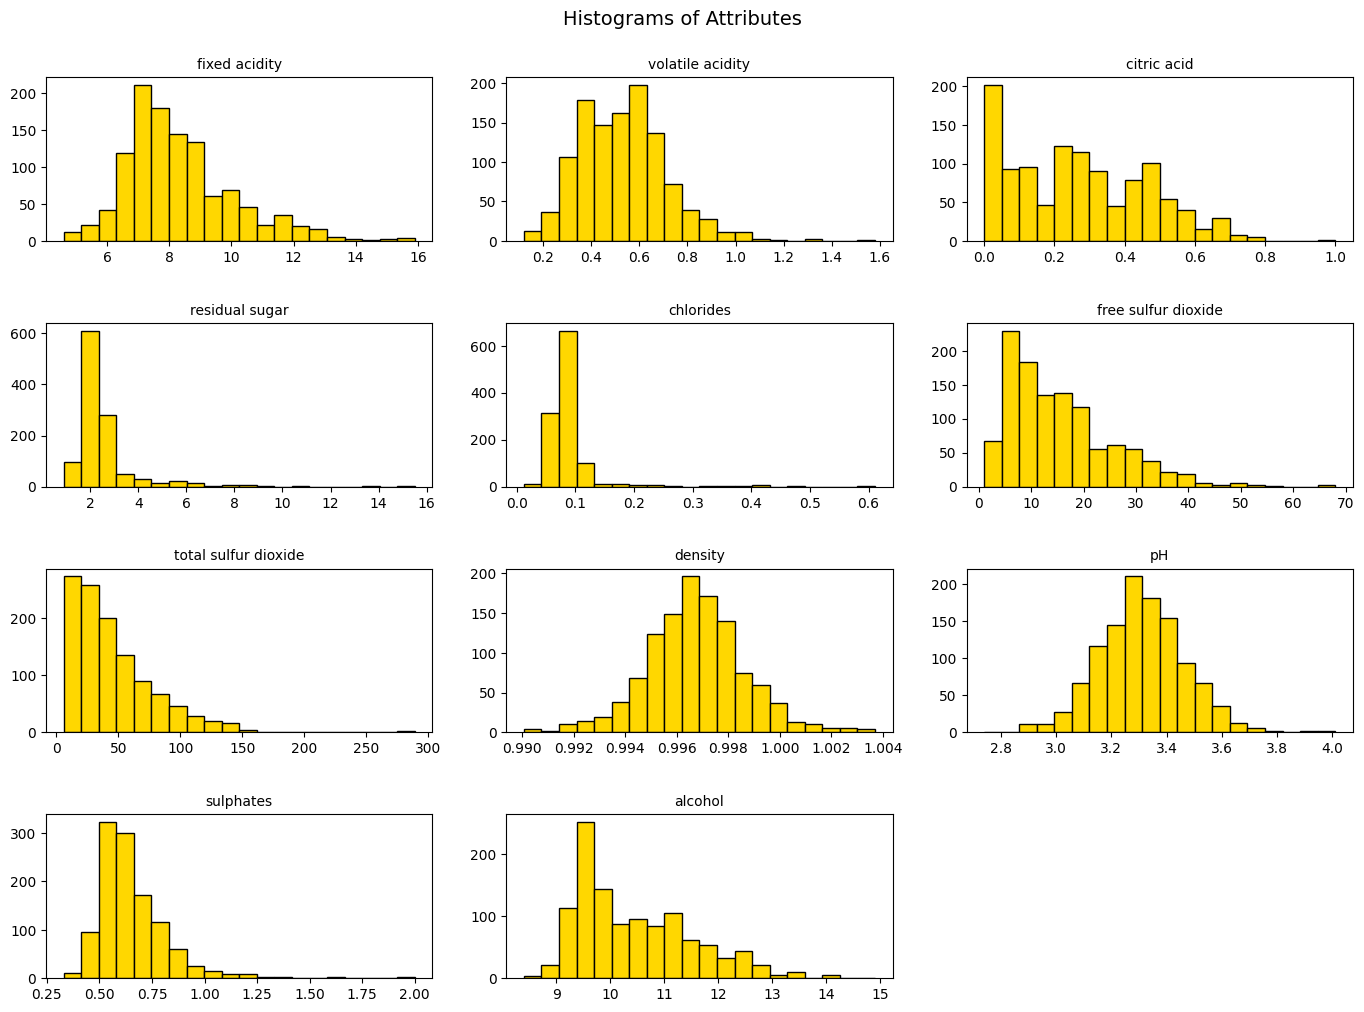

In [3]:
attributes = X.columns
num_attributes = len(attributes)
cols = 3
rows = (num_attributes + cols - 1) // cols

plt.figure(figsize=(14, 10))
for i, column in enumerate(attributes):
    plt.subplot(rows, cols, i + 1)
    plt.hist(df[column], bins=20, color='gold', edgecolor='black')
    plt.title(column, fontsize=10)
    plt.tight_layout(pad=2.0)
plt.suptitle("Histograms of Attributes", fontsize=14, y=1.02)
plt.subplots_adjust(hspace=0.5)
plt.show()

### Then we plot class-wise histograms for each attribute

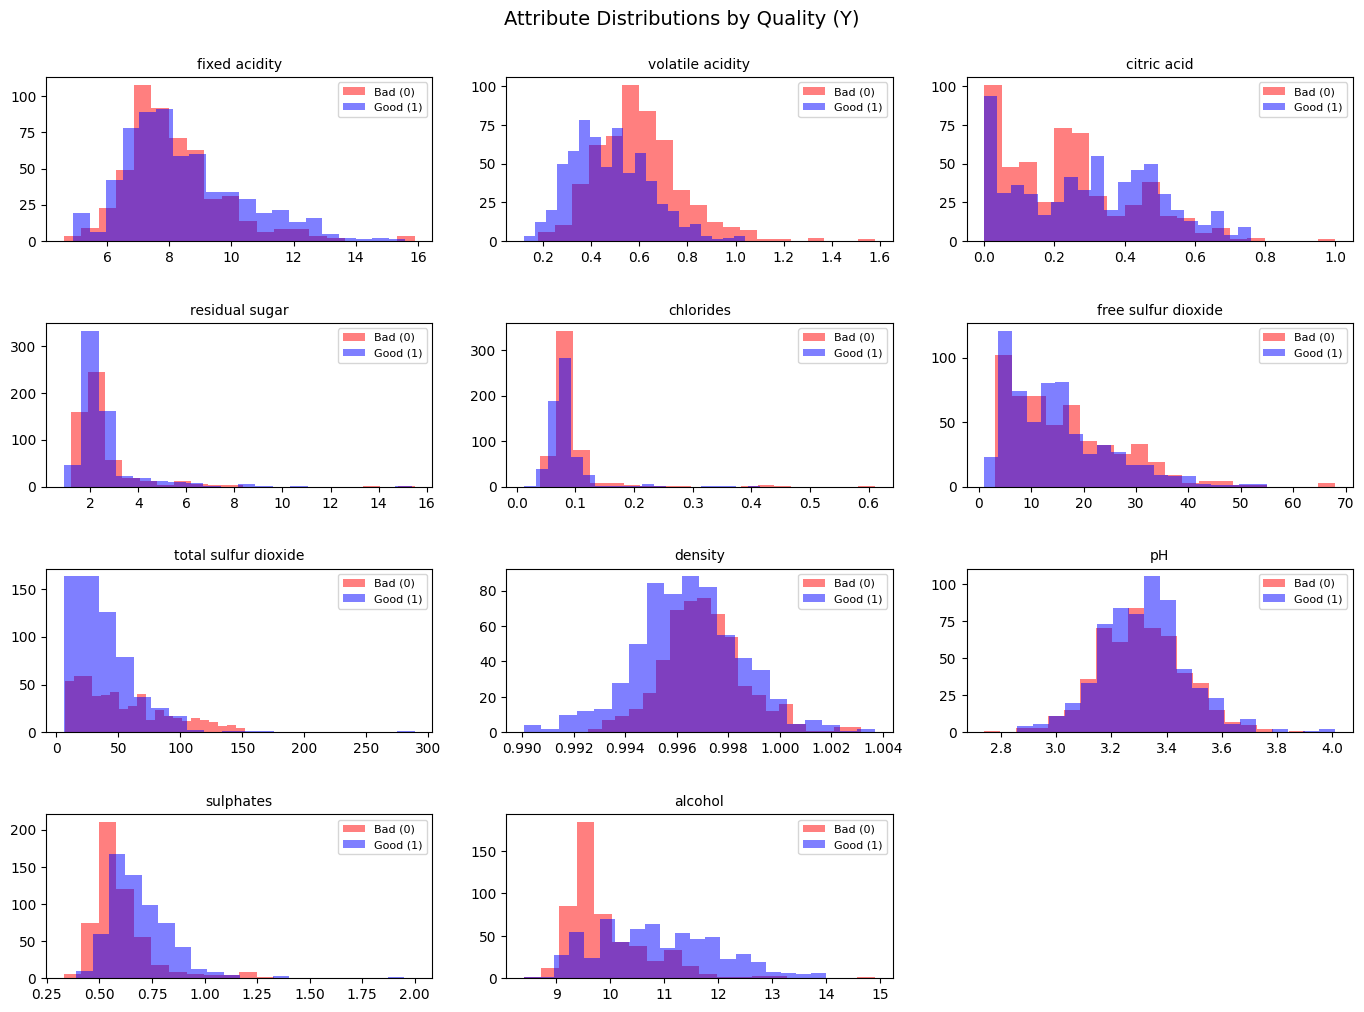

In [4]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(attributes):
    plt.subplot(rows, cols, i + 1)
    plt.hist(df[df["quality"] == 0][column], bins=20, alpha=0.5, label='Bad (0)', color='red')
    plt.hist(df[df["quality"] == 1][column], bins=20, alpha=0.5, label='Good (1)', color='blue')
    plt.title(column, fontsize=10)
    plt.legend(fontsize=8)
    plt.tight_layout(pad=2.0)
plt.suptitle("Attribute Distributions by Quality (Y)", fontsize=14, y=1.02)
plt.subplots_adjust(hspace=0.5)
plt.show()

### Then we run SVM classification with 10 runs and GridSearch

In [5]:
accuracies = []
best_params_list = []

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': [1,0.1,0.01]
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for run in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=np.random.randint(10000)
    )
    svm = SVC()
    grid_search = GridSearchCV(svm, param_grid, cv=5)
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)


    accuracies.append(acc)
    best_params_list.append(best_params)



### Finally we show results for each run

In [6]:
print("Best Hyperparameters per Run:")
for i, params in enumerate(best_params_list, start=1):
    print(f"Run {i}: {params}")

print("\nAccuracies per Run:")
for i, acc in enumerate(accuracies, start=1):
    print(f"Run {i}: {acc:.4f}")

print(f"\nAverage Accuracy: {np.mean(accuracies):.4f}")
print(f"Standard Deviation: {np.std(accuracies):.4f}")

Best Hyperparameters per Run:
Run 1: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Run 2: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Run 3: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 4: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Run 5: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 6: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 7: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Run 8: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Run 9: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 10: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Accuracies per Run:
Run 1: 0.7555
Run 2: 0.7686
Run 3: 0.8035
Run 4: 0.7991
Run 5: 0.7598
Run 6: 0.7555
Run 7: 0.7729
Run 8: 0.7380
Run 9: 0.7642
Run 10: 0.7729

Average Accuracy: 0.7690
Standard Deviation: 0.0189


## Density Analysis

### First we select attribute - 'Volatile Acidity'

### Then we delete overlapping samples and create new Dataset

In [7]:
import pandas as pd

df = pd.read_csv("Wine_Test_01.csv")

# Filtering conditions to reduce class overlap for 'volatile acidity' :
# Keeping Y=0 samples where volatile_acidity >= 0.4
# Keeping Y=1 samples where volatile_acidity <= 0.7

filtered_df = df[((df['quality'] == 0) & (df['volatile acidity'] >= 0.4)) | ((df['quality'] == 1) & (df['volatile acidity'] <= 0.7))]

filtered_df.to_csv("Wine_Test_01_Modified.csv", index=False)

### Original Dataset

In [8]:
print(f"Original dataset size: {df.shape[0]}")
df.head(5)

Original dataset size: 1143


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


### Modified Dataset

In [9]:
print(f"Filtered dataset size: {filtered_df.shape[0]}")
filtered_df.head(5)

Filtered dataset size: 1023


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


### Now we compare Original and New histograms for volatile acidity (before & after filtering)

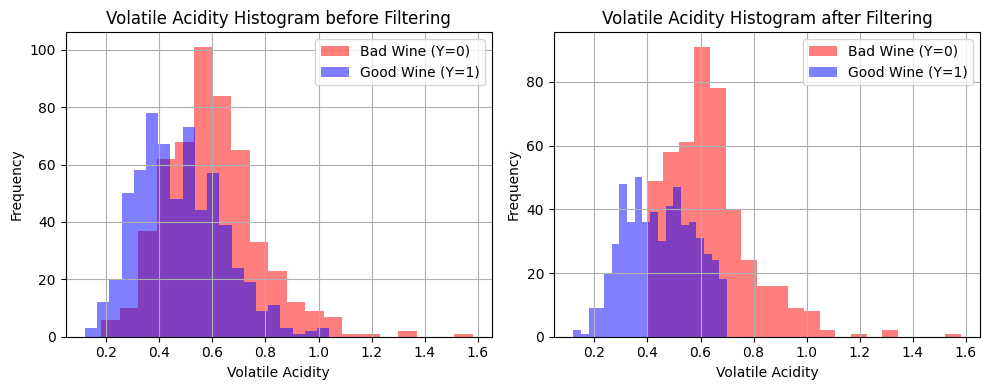

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df[df['quality'] == 0]['volatile acidity'].hist(alpha=0.5, color='red', label='Bad Wine (Y=0)', bins=20)
df[df['quality'] == 1]['volatile acidity'].hist(alpha=0.5, color='blue', label='Good Wine (Y=1)', bins=20)
plt.title("Volatile Acidity Histogram before Filtering")
plt.xlabel("Volatile Acidity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
filtered_df[filtered_df['quality'] == 0]['volatile acidity'].hist(alpha=0.5, color='red', label='Bad Wine (Y=0)', bins=20)
filtered_df[filtered_df['quality'] == 1]['volatile acidity'].hist(alpha=0.5, color='blue', label='Good Wine (Y=1)', bins=20)
plt.title("Volatile Acidity Histogram after Filtering")
plt.xlabel("Volatile Acidity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Then we re-run 10 SVM runs with modified dataset

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

df_mod = pd.read_csv("Wine_Test_01_Modified.csv")

X_mod = df_mod.drop("quality", axis=1)
y_mod = df_mod["quality"]

scaler = StandardScaler()
X_mod_scaled = scaler.fit_transform(X_mod)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1,0.1,0.01],
    'kernel': ['linear', 'rbf']
}

best_params_mod = []
accuracies_mod = []

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_mod_scaled, y_mod, test_size=0.2, random_state=i)

    grid = GridSearchCV(SVC(), param_grid, cv=5)
    grid.fit(X_train, y_train)


    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies_mod.append(acc)
    best_params_mod.append(grid.best_params_)

print("Best Hyperparameters per Run:")
for i, params in enumerate(best_params_mod):
    print(f"Run {i+1}: {params}")

print("\nAccuracies per Run:")
for i, acc in enumerate(accuracies_mod):
    print(f"Run {i+1}: {acc:.4f}")

print(f"\nAverage Accuracy: {np.mean(accuracies_mod):.4f}")
print(f"Standard Deviation: {np.std(accuracies_mod):.4f}")

Best Hyperparameters per Run:
Run 1: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 2: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 3: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 4: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 5: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 6: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 7: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 8: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 9: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 10: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Accuracies per Run:
Run 1: 0.7902
Run 2: 0.8293
Run 3: 0.7902
Run 4: 0.8098
Run 5: 0.8049
Run 6: 0.8049
Run 7: 0.8098
Run 8: 0.8146
Run 9: 0.8049
Run 10: 0.7805

Average Accuracy: 0.8039
Standard Deviation: 0.0132


###  Interpretation and Comparison with above results

## Principal Component Analysis

### Apply PCA and Display “Number of Components” vs “Cumulative Variance

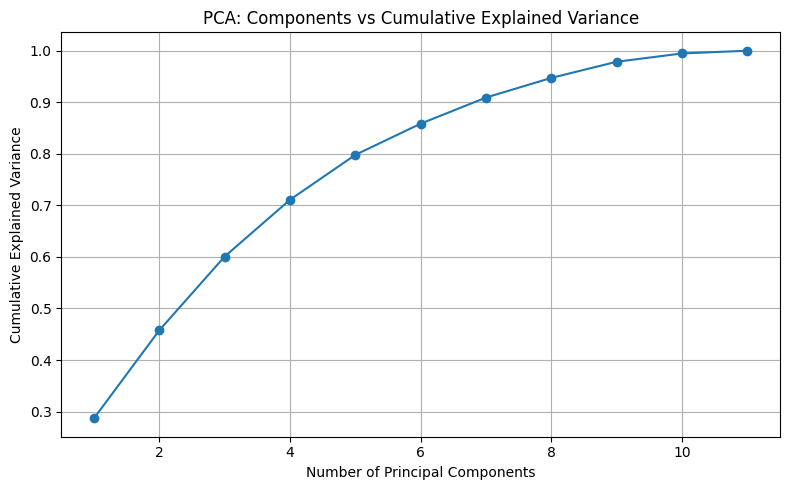

Number of components selected to retain ≥95% variance: 9


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# to standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X is the original df without quality col from task 1

# PCA
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Components vs Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components selected to retain ≥95% variance: {n_components}")

We first standardized our data to make sure all features have the same scale. Then, we applied PCA to transform the data into new components that capture the most variance. And finally, we chose the smallest number of components that together explain at least 95% of the total variance.

###  PCA + SVM with Grid Search

In [13]:
from sklearn.decomposition import PCA

# init
n_components = 9 # from task 3.a
accuracies_pca = []
best_params_pca = []
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': [1, 0.1, 0.01]
} # from task 1 SVM


for run in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=np.random.randint(10000)
    )
    
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)  # Apply same transformation to test data
    
    svm = SVC()
    grid_search = GridSearchCV(svm, param_grid, cv=5)
    grid_search.fit(X_train_pca, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)

    accuracies_pca.append(acc)
    best_params_pca.append(best_params)

# Displya results
print("Best Hyperparameters per Run (PCA):")
for i, params in enumerate(best_params_pca, start=1):
    print(f"Run {i}: {params}")

print("\nAccuracies per Run (PCA):")
for i, acc in enumerate(accuracies_pca, start=1):
    print(f"Run {i}: {acc:.4f}")

print(f"\nAverage Accuracy with PCA: {np.mean(accuracies_pca):.4f}")
print(f"Standard Deviation with PCA: {np.std(accuracies_pca):.4f}")


Best Hyperparameters per Run (PCA):
Run 1: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 2: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 3: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Run 4: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 5: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 6: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 7: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Run 8: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 9: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Run 10: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Accuracies per Run (PCA):
Run 1: 0.7511
Run 2: 0.7686
Run 3: 0.7205
Run 4: 0.7904
Run 5: 0.7424
Run 6: 0.7991
Run 7: 0.7991
Run 8: 0.7424
Run 9: 0.7293
Run 10: 0.7293

Average Accuracy with PCA: 0.7572
Standard Deviation with PCA: 0.0285


We set the number of PCA components to 9 based on our previous analysis. Then, we ran a loop 10 times where, for each run, we split the data randomly into training and test sets. We applied PCA on the training data and transformed both training and test data accordingly. Next, we trained an SVM classifier using grid search to find the best hyperparameters over a range of options. We evaluated the best model on the test data and recorded its accuracy and the best parameters are found. Finally, we displayed the best hyperparameters and accuracy for each run, along with the average accuracy and its variation across all runs.

### Comparison of SVM Performance: With vs Without PCA (comparing results of 1 and 3)

## Recursive Feature Elimination

In [14]:
df = pd.read_csv("Wine_Test_01.csv")
X = df.drop('quality', axis=1)
y = df['quality']


# **PreProcessing the data**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)


[[ 0.1426802  -1.40273053  1.5096933  ... -0.09314751  0.56821234
   0.05661327]
 [ 0.96843134 -1.17920341  1.5096933  ... -1.07474038  0.4477703
   0.89445566]
 [ 0.3786091  -1.23508519  0.4833938  ...  0.56124774  0.20688622
   1.26683005]
 ...
 [-0.50612428 -1.01155806  0.32944888 ...  0.29948964 -0.33510296
   1.35992365]
 [-0.21121315  0.21784112  0.22681893 ... -0.15858703  0.20688622
  -0.87432272]
 [-0.44714205 -0.06156778  0.6886537  ... -0.35490561 -0.09421888
   1.26683005]]


# **RFE estimator and Selector**

In [16]:
from sklearn.feature_selection import RFE


estimator = SVC(kernel='linear', C=1000, gamma=0.1)
selector = RFE(estimator, n_features_to_select=8)
selector = selector.fit(X_train_scaled, y_train)

selected_features = X.columns[selector.support_]
print("Selected Features:", selected_features.tolist())


Selected Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'alcohol']


In [17]:
X_train_reduced = X_train_scaled[:, selector.support_]
X_test_reduced = X_test_scaled[:, selector.support_]

print(X_train_reduced)


[[ 0.1426802  -1.40273053  1.5096933  ...  1.79122276  0.56821234
   0.05661327]
 [ 0.96843134 -1.17920341  1.5096933  ... -1.18572018  0.4477703
   0.89445566]
 [ 0.3786091  -1.23508519  0.4833938  ... -0.21429669  0.20688622
   1.26683005]
 ...
 [-0.50612428 -1.01155806  0.32944888 ... -0.62166783 -0.33510296
   1.35992365]
 [-0.21121315  0.21784112  0.22681893 ...  1.03915297  0.20688622
  -0.87432272]
 [-0.44714205 -0.06156778  0.6886537  ... -0.80968528 -0.09421888
   1.26683005]]


In [18]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['linear','rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=10)
grid_combinations = list(ParameterGrid(param_grid))

print("All hyperparameter combinations:")
for i, params in enumerate(grid_combinations):
    print(f"Set {i+1}: {params}")
grid.fit(X_train_reduced, y_train)
print()
print("Best Parameters:", grid.best_params_)


All hyperparameter combinations:
Set 1: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Set 2: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Set 3: {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}
Set 4: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Set 5: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
Set 6: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Set 7: {'C': 1, 'gamma': 1, 'kernel': 'linear'}
Set 8: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Set 9: {'C': 1, 'gamma': 0.1, 'kernel': 'linear'}
Set 10: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Set 11: {'C': 1, 'gamma': 0.01, 'kernel': 'linear'}
Set 12: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Set 13: {'C': 10, 'gamma': 1, 'kernel': 'linear'}
Set 14: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Set 15: {'C': 10, 'gamma': 0.1, 'kernel': 'linear'}
Set 16: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Set 17: {'C': 10, 'gamma': 0.01, 'kernel': 'linear'}
Set 18: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [19]:
y_pred = grid.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy with RFE-selected features:", accuracy)


Test Accuracy with RFE-selected features: 0.777292576419214


4.1 -> d -> 4th point : Slight Improvement with RFE

The test accuracy improved from 0.76 to 0.7773 -   a +1.7% gain.

This suggests that RFE helped by removing irrelevant or noisy features.

Model Simplicity Improved

RFE reduced the number of features (e.g., from 11 to 8).

This makes the model:

Faster to train

Easier to interpret

Less likely to overfit on small or noisy datasets